In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import contextlib
import copy
import io
import os
import queue
import threading
from datetime import date
from itertools import product
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error, r2_score

from aquacrop import AquaCrop, Crop, Soil, Weather
from aquacrop_slovenia import config
from aquacrop_slovenia.diagnostics import nse, kge, mkge, kge_r, kge_beta, kge_alpha, mkge_alpha
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison, plot_yield_scatter, plot_yield_timeseries_residuals
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison, get_co2_for_aquacrop, get_station_weather
from aquacrop_slovenia.parameter_defaults_rakican import (
    rakican_soil_layers,
    rakican_curve_number,
    rakican_readily_evaporable_water,
    rakican_maize_params,
    rakican_optimal_management,
    rakican_initial_cond,
)

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
LOCATION = "rakican"
MAX_WORKERS = os.cpu_count()

simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 12, 31),
        "planting_date": date(year, 4, 20),
        "is_seeding_year": True,
    }
    for year in range(1993, 2024)
    if year not in [1998, 2017, 2023]
]

temperatures, eto, rain = get_station_weather(355)
historical_co2 = get_co2_for_aquacrop("historical")

weather = Weather(
    location=LOCATION,
    temperatures=temperatures,
    eto_values=eto,
    rainfall_values=rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2,
)

soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} loamy sand soil",
    soil_layers=rakican_soil_layers,
    curve_number=rakican_curve_number,
    readily_evaporable_water=rakican_readily_evaporable_water,
)

observed_biomass = get_yield_for_comparison(LOCATION, "biomass", "A", "N3")
observed_grain = get_yield_for_comparison(LOCATION, "grain", "A", "N3")

INTEGER_PARAMS = {name for name, val in rakican_maize_params.items() if isinstance(val, int)}

In [4]:
# Parameters to search and their grid values
grid_params = {
    "gdd_flowering":        np.linspace(750, 950, 4),
    "gdd_flowering_length": np.linspace(120, 240, 4),
    #"min_rooting_depth":    np.linspace(0.2, 0.5, 4),
    "max_rooting_depth":    np.linspace(1.5, 3.0, 4),
    "ksat":                 np.array([100., 500., 1000., 2200., 5000.]),
    "cgc_gdd":              np.linspace(0.009, 0.016, 4),
}

# Soil params are applied to non-impermeable layers only (penetrability > 0)
SOIL_PARAMS = {"ksat"}

param_names = list(grid_params.keys())
grid_combinations = list(product(*grid_params.values()))

grid_shape = " x ".join(str(len(v)) for v in grid_params.values())
print(f"Grid: {grid_shape} = {len(grid_combinations):,} combinations")
print(f"Workers: {MAX_WORKERS}")

Grid: 4 x 4 x 4 x 5 x 4 = 1,280 combinations
Workers: 28


In [5]:
# Pre-create one working directory per worker to avoid conflicts
worker_dirs = []
for i in range(MAX_WORKERS):
    d = config.RAMDISK_DIR / f"grid_rakican_{i}"
    d.mkdir(parents=True, exist_ok=True)
    worker_dirs.append(d)

dir_queue = queue.Queue()
for d in worker_dirs:
    dir_queue.put(d)

print(f"Worker directories: {[str(d) for d in worker_dirs]}")

Worker directories: ['E:aquacrop\\grid_rakican_0', 'E:aquacrop\\grid_rakican_1', 'E:aquacrop\\grid_rakican_2', 'E:aquacrop\\grid_rakican_3', 'E:aquacrop\\grid_rakican_4', 'E:aquacrop\\grid_rakican_5', 'E:aquacrop\\grid_rakican_6', 'E:aquacrop\\grid_rakican_7', 'E:aquacrop\\grid_rakican_8', 'E:aquacrop\\grid_rakican_9', 'E:aquacrop\\grid_rakican_10', 'E:aquacrop\\grid_rakican_11', 'E:aquacrop\\grid_rakican_12', 'E:aquacrop\\grid_rakican_13', 'E:aquacrop\\grid_rakican_14', 'E:aquacrop\\grid_rakican_15', 'E:aquacrop\\grid_rakican_16', 'E:aquacrop\\grid_rakican_17', 'E:aquacrop\\grid_rakican_18', 'E:aquacrop\\grid_rakican_19', 'E:aquacrop\\grid_rakican_20', 'E:aquacrop\\grid_rakican_21', 'E:aquacrop\\grid_rakican_22', 'E:aquacrop\\grid_rakican_23', 'E:aquacrop\\grid_rakican_24', 'E:aquacrop\\grid_rakican_25', 'E:aquacrop\\grid_rakican_26', 'E:aquacrop\\grid_rakican_27']


In [6]:
def evaluate_params(param_values):
    """Run one grid point and return parameter values + all scores for both grain and biomass."""
    working_dir = dir_queue.get()
    try:
        params = copy.deepcopy(rakican_maize_params)
        soil_vals = {}
        for name, val in zip(param_names, param_values):
            if name in SOIL_PARAMS:
                soil_vals[name] = float(val)
            else:
                params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

        if soil_vals:
            layers = copy.deepcopy(rakican_soil_layers)
            for layer in layers:
                if layer.penetrability > 0:  # skip the impermeable bottom layer
                    for k, v in soil_vals.items():
                        setattr(layer, k, v)
            current_soil = Soil(
                name=f"{LOCATION} soil",
                description=f"{LOCATION} loamy sand soil",
                soil_layers=layers,
                curve_number=rakican_curve_number,
                readily_evaporable_water=rakican_readily_evaporable_water,
            )
        else:
            current_soil = soil

        crop = Crop(
            name=f"{LOCATION} maize",
            description="grid search",
            params=params,
        )

        simulation = AquaCrop(
            simulation_periods=simulation_periods,
            crop=crop,
            soil=current_soil,
            management=rakican_optimal_management,
            initial_conditions=rakican_initial_cond,
            climate=weather,
            working_dir=working_dir,
            need_daily_output=False,
            need_seasonal_output=True,
            need_harvest_output=False,
            need_evaluation_output=False,
        )

        nan_metrics = {f"{prefix}_{s}": np.nan
                       for prefix in ("biomass", "grain")
                       for s in ["rmse", "r2", "nse", "kge", "mkge", "kge_r", "kge_beta", "kge_alpha", "mkge_alpha"]}

        try:
            with contextlib.redirect_stdout(io.StringIO()):
                results = simulation.run()
        except Exception:
            return {**dict(zip(param_names, param_values)), **nan_metrics}

        seasonal = results["season"][["Year1", "BioMass", "Y(dry)"]].rename(
            columns={"Year1": "year", "BioMass": "biomass_modeled", "Y(dry)": "grain_modeled"}
        )

        def compute_metrics(observed_df, modeled_col, prefix):
            merged = observed_df.merge(seasonal[["year", modeled_col]], on="year")
            # Filter out rows with NaN values in either observed or modeled data
            valid_mask = merged["yield"].notna() & merged[modeled_col].notna()
            merged_clean = merged[valid_mask]

            # Check if we have enough valid data points
            if len(merged_clean) < 2:  # Need at least 2 points for meaningful metrics
                return {f"{prefix}_rmse": None, f"{prefix}_r2": None,
                        f"{prefix}_nse": None, f"{prefix}_kge": None}

            y_obs = merged_clean["yield"].values
            y_mod = merged_clean[modeled_col].values

            return {
                f"{prefix}_rmse":       root_mean_squared_error(y_obs, y_mod),
                f"{prefix}_r2":         r2_score(y_obs, y_mod),
                f"{prefix}_nse":        nse(y_mod, y_obs),
                f"{prefix}_kge":        kge(y_mod, y_obs),
                f"{prefix}_mkge":       mkge(y_mod, y_obs),
                f"{prefix}_kge_r":      kge_r(y_mod, y_obs),
                f"{prefix}_kge_beta":   kge_beta(y_mod, y_obs),
                f"{prefix}_kge_alpha":  kge_alpha(y_mod, y_obs),
                f"{prefix}_mkge_alpha": mkge_alpha(y_mod, y_obs),
            }

        return {
            **dict(zip(param_names, param_values)),
            **compute_metrics(observed_biomass, "biomass_modeled", "biomass"),
            **compute_metrics(observed_grain, "grain_modeled", "grain"),
        }
    finally:
        dir_queue.put(working_dir)

In [7]:
total = len(grid_combinations)
results_list = []

print(f"Running {total:,} simulations with {MAX_WORKERS} workers...")
print(f"Approximate running time: {total // 340} min")

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [executor.submit(evaluate_params, combo) for combo in grid_combinations]
    for future in as_completed(futures):
        results_list.append(future.result())

results_df = pd.DataFrame(results_list).sort_values("grain_rmse").reset_index(drop=True)
print(f"\nComplete. Failed runs: {results_df['biomass_rmse'].isna().sum()}")

Running 1,280 simulations with 28 workers...
Approximate running time: 3 min
Results successfully parsed


In [8]:
output_path = config.RESULTS_DIR / "grid_search_rakican_1.pkl"
results_df.to_pickle(output_path)
print(f"Saved {len(results_df):,} rows to {output_path}")

In [9]:
output_path = config.RESULTS_DIR / "grid_search_rakican_1.pkl"
results_df = pd.read_pickle(output_path)

In [17]:
results_df.sort_values("grain_mkge", ascending=False).reset_index(drop=True)

,gdd_flowering,gdd_flowering_length,max_rooting_depth,ksat,cgc_gdd,biomass_rmse,biomass_r2,biomass_nse,biomass_kge,biomass_mkge,...,biomass_mkge_alpha,grain_rmse,grain_r2,grain_nse,grain_kge,grain_mkge,grain_kge_r,grain_kge_beta,grain_kge_alpha,grain_mkge_alpha
0,750.0,120.0,1.5,5000.0,0.016,6.737616,-2.355950,-2.355950,0.266034,0.159374,...,0.374871,2.459145,-0.246036,-0.246036,0.401808,0.328506,0.566644,1.212858,0.646832,0.533312
1,750.0,120.0,1.5,2200.0,0.016,6.737616,-2.355950,-2.355950,0.266034,0.159374,...,0.374871,2.459145,-0.246036,-0.246036,0.401808,0.328506,0.566644,1.212858,0.646832,0.533312
2,750.0,120.0,1.5,1000.0,0.016,6.740608,-2.358931,-2.358931,0.265809,0.159134,...,0.374897,2.460511,-0.247421,-0.247421,0.401396,0.328100,0.566121,1.212992,0.646857,0.533274
3,750.0,120.0,1.5,500.0,0.016,6.760076,-2.378362,-2.378362,0.263789,0.157131,...,0.374190,2.468321,-0.255353,-0.255353,0.399446,0.326019,0.564286,1.214057,0.646449,0.532470
4,750.0,120.0,1.5,100.0,0.016,6.800806,-2.419194,-2.419194,0.260015,0.153303,...,0.373458,2.487617,-0.275056,-0.275056,0.395278,0.321755,0.558027,1.216172,0.648405,0.533152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1275,950.0,240.0,3.0,1000.0,0.009,4.009581,-0.188505,-0.188505,-0.068434,-0.082670,...,0.138220,6.045187,-6.529773,-6.529773,-0.342407,-0.386557,-0.004642,0.286123,0.467899,1.635306
1276,950.0,240.0,3.0,2200.0,0.009,4.009801,-0.188635,-0.188635,-0.068813,-0.083029,...,0.138060,6.045248,-6.529925,-6.529925,-0.342462,-0.386627,-0.004713,0.286119,0.467902,1.635342
1277,950.0,240.0,3.0,5000.0,0.009,4.009801,-0.188635,-0.188635,-0.068813,-0.083029,...,0.138060,6.045248,-6.529925,-6.529925,-0.342462,-0.386627,-0.004713,0.286119,0.467902,1.635342
1278,950.0,240.0,2.5,2200.0,0.009,3.990751,-0.177368,-0.177368,-0.061316,-0.075520,...,0.139009,6.047992,-6.536762,-6.536762,-0.342524,-0.386695,-0.004168,0.285671,0.467316,1.635851


In [22]:
# Re-run with the best parameter set to get full seasonal results for plotting
results_df_sorted = results_df.sort_values("biomass_mkge", ascending=False).reset_index(drop=True)
best = results_df_sorted.iloc[0]

best_params = copy.deepcopy(rakican_maize_params)
best_soil_vals = {}
for name in param_names:
    val = best[name]
    if name in SOIL_PARAMS:
        best_soil_vals[name] = float(val)
    else:
        best_params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

if best_soil_vals:
    best_layers = copy.deepcopy(rakican_soil_layers)
    for layer in best_layers:
        if layer.penetrability > 0:  # skip the impermeable bottom layer
            for k, v in best_soil_vals.items():
                setattr(layer, k, v)
    print(best_layers)
    best_soil = Soil(
        name=f"{LOCATION} soil",
        description=f"{LOCATION} loamy sand soil",
        soil_layers=best_layers,
        curve_number=rakican_curve_number,
        readily_evaporable_water=rakican_readily_evaporable_water,
    )
else:
    best_soil = soil

best_crop = Crop(
    name=f"{LOCATION} maize (best grid)",
    description="best grid search parameters",
    params=best_params,
)

best_dir = config.RAMDISK_DIR / "grid_rakican_best"
best_dir.mkdir(parents=True, exist_ok=True)

best_simulation = AquaCrop(
    simulation_periods=simulation_periods,
    crop=best_crop,
    soil=best_soil,
    management=rakican_optimal_management,
    initial_conditions=rakican_initial_cond,
    climate=weather,
    working_dir=best_dir,
    need_daily_output=False,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False,
)

best_results = best_simulation.run()
best_seasonal = best_results["season"]

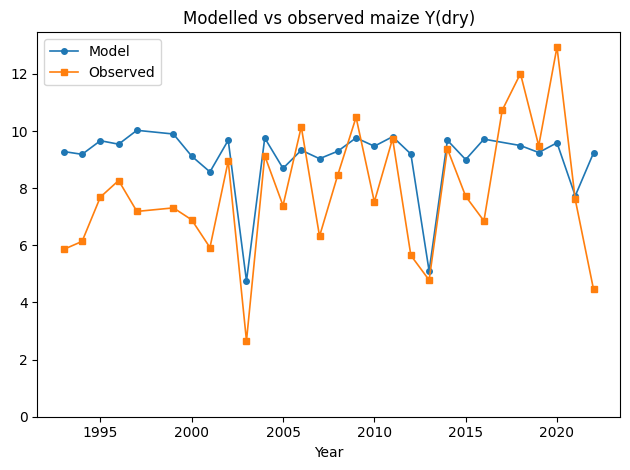

In [23]:
plot_yield_timeseries_comparison(best_seasonal, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)")

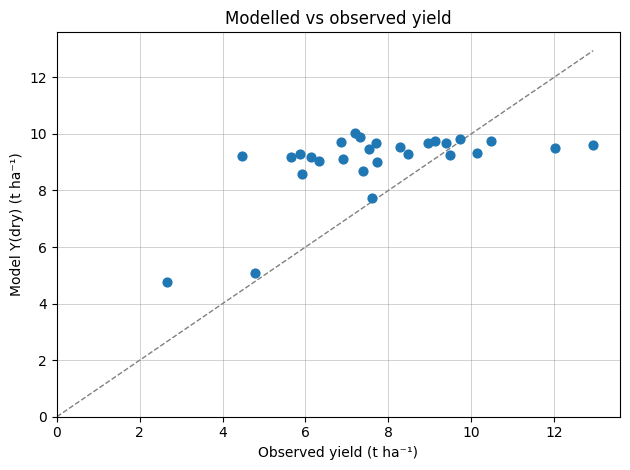

In [13]:
plot_yield_scatter(best_seasonal, get_yield(LOCATION, "grain", "A", "N3"))

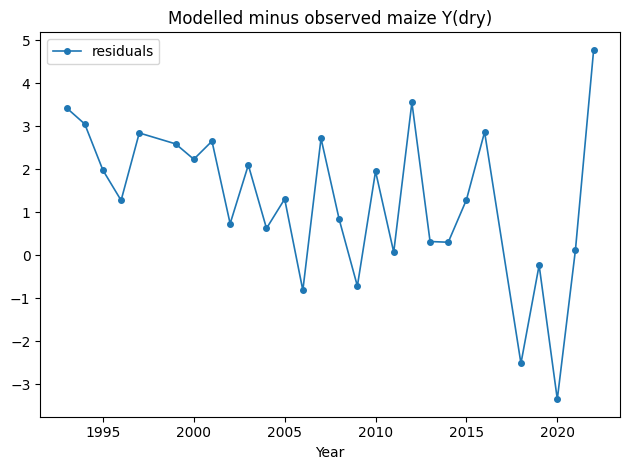

In [14]:
plot_yield_timeseries_residuals(best_seasonal, get_yield_for_comparison(LOCATION, "grain", "A", "N3"), "Y(dry)")

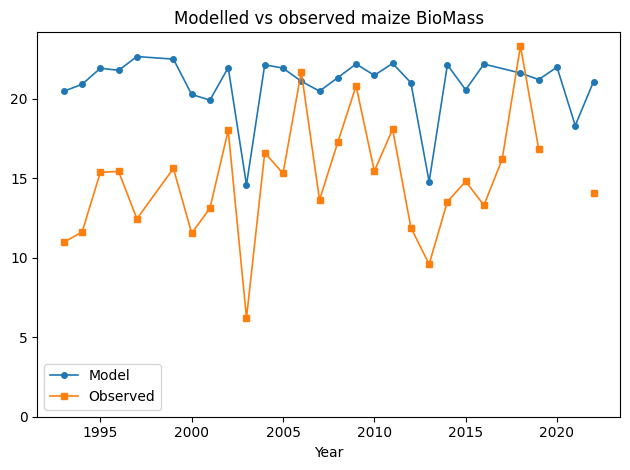

In [21]:
plot_yield_timeseries_comparison(best_seasonal, get_yield(LOCATION, "biomass", "A", "N3"), "BioMass")

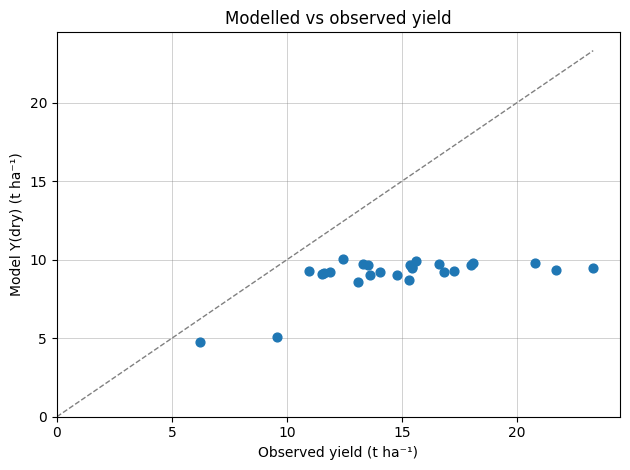

In [16]:
plot_yield_scatter(best_seasonal, get_yield(LOCATION, "biomass", "A", "N3"))